# SciPAS Transport Solver — Analytical Profile Benchmark

Validation of `profile_solver` against the **closed-form solution** for a single
homogeneous layer with a *uniform* source $g(z)=I_0$ and constant coefficients
$(D,\;v=\mu E,\;\lambda)$.

The solver integrates
$$\frac{d}{dz}\!\Big[D\,\frac{dc}{dz}\Big]-v\,\frac{dc}{dz}-\lambda\,c=-g(z),$$
with **radiative boundary conditions** — the relations the FD scheme actually
enforces, and the ones the analytical solution below is built on:
$$c'(0)=\frac{c(0)}{L_a}\quad\text{(surface, absorption length }L_a),\qquad
  c'(S)=-\frac{c(S)}{L}\quad\Big(L=\sqrt{D/\lambda}\Big)\ \text{(back)},$$
where $S$ is the sample length.

> **Numerical note (why a moderate $L$).** The particular solution is the
> constant $I_0/\lambda$. Since $\lambda=D/L^2$, pushing $L\!\to\!\infty$ sends
> $I_0/\lambda\!\to\!\infty$, and the physical $O(c)$ profile is then recovered
> as the *difference* of two huge terms ($I_0/\lambda$ and
> $B\,e^{\kappa_2 z}\!\approx\!-I_0/\lambda$) — a catastrophic cancellation in
> the analytical **reference** (not a solver error) that costs
> $\sim\log_{10}(I_0/\lambda)$ significant digits. We therefore use a moderate
> $L=100$ nm, where $I_0/\lambda$ stays $O(1)$, the reference is full precision,
> and agreement is limited only by the FD step size ($\sim\!10^{-8}$).

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from scipas.transport import profile_solver
from scipas.model import Material, Layer, Sample

In [2]:
def run_solver(D, v, lam, L_a, S, mesh, field=False):
    """Run profile_solver for one homogeneous layer with a uniform source I0 = 1/S."""
    layer  = Layer(width=S, material=Material(diffusion=D, mobility=v,
                                              bulk_annihilation_rate=lam))
    sample = Sample(layers=[layer], absorption_length=L_a)
    z   = np.linspace(0, S, mesh)
    I0  = 1.0 / S
    src = xr.DataArray(np.full(mesh, I0), coords={'x': z})
    ef  = xr.DataArray(np.full(mesh, 1.0), coords={'x': z}) if field else None
    c   = profile_solver(src, sample, electric_field=ef, mesh_size=mesh)
    return z, c.values, I0


def compare_plot(z, c_ref, c_num, title):
    """Top: analytical vs numerical.  Bottom: pointwise relative difference."""
    mask = np.abs(c_ref) > 1e-3 * np.abs(c_ref).max()
    rel  = np.abs(c_num - c_ref) / np.abs(c_ref)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5), sharex=True,
                                   gridspec_kw={'height_ratios': [2, 1]})
    ax1.plot(z, c_ref, '-',  color='steelblue', lw=2,   label='Analytical')
    ax1.plot(z, c_num, '--', color='crimson',   lw=1.5, label='SciPAS FD solver')
    ax1.set_ylabel('c(z)  [a.u.]'); ax1.set_title(title)
    ax1.legend(); ax1.grid(alpha=0.3)
    ax2.semilogy(z[mask], rel[mask], color='black', lw=1.2)
    ax2.set_xlabel('Depth z [nm]')
    ax2.set_ylabel(r'$|c_{FD}-c_{exact}|/|c_{exact}|$')
    ax2.grid(alpha=0.3, which='both')
    fig.tight_layout(); plt.show()
    print(f'max rel error = {rel[mask].max():.2e}   median = {np.median(rel[mask]):.2e}')

## 1. General case
For constant coefficients the homogeneous roots are
$$\kappa_{1,2}=\frac{v}{2D}\pm\sqrt{\Big(\frac{v}{2D}\Big)^2+\frac1{L^2}},
  \qquad \lambda=\frac{D}{L^2},$$
and $c(z)=A\,e^{\kappa_1 z}+B\,e^{\kappa_2 z}+I_0/\lambda$. The two radiative BCs
$c'(0)=c(0)/L_a$ and $c'(S)=-c(S)/L$ fix $A,B$.

We use a **moderate $L=100$ nm** (so $I_0/\lambda$ stays $O(1)$ and the
reference is full precision).

In [3]:
def c_general(z, I0, D, v, L_a, L, S):
    lam = D / L**2
    k1 = v / (2 * D) + np.sqrt((v / (2 * D))**2 + 1 / L**2)
    k2 = v / (2 * D) - np.sqrt((v / (2 * D))**2 + 1 / L**2)
    # unknowns: A_tilde = A*exp(k1*S)  and  B   (stable BC system)
    M   = np.array([[np.exp(-k1 * S) * (k1 - 1 / L_a),  k2 - 1 / L_a],
                    [k1 + 1 / L,                        np.exp(k2 * S) * (k2 + 1 / L)]])
    rhs = np.array([(I0 / lam) / L_a, -(I0 / lam) / L])
    A_tilde, B = np.linalg.solve(M, rhs)
    return A_tilde * np.exp(k1 * (z - S)) + B * np.exp(k2 * z) + I0 / lam

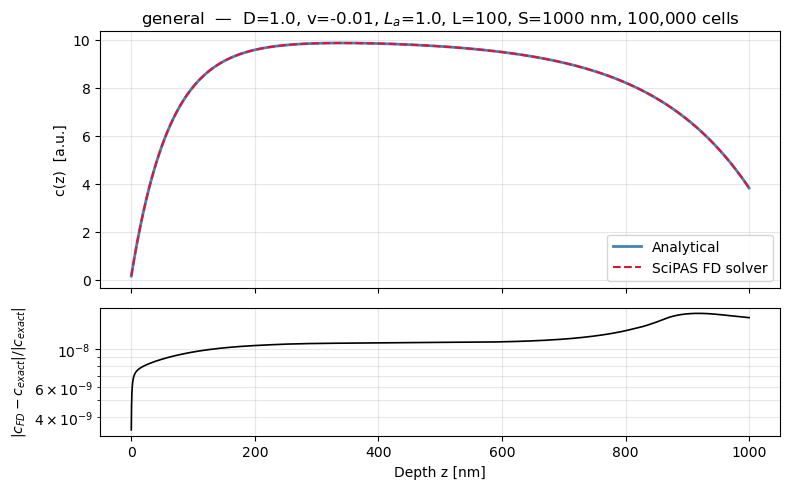

max rel error = 1.63e-08   median = 1.10e-08


In [4]:
D, v, L_a, L, S, mesh = 1.0, -1e-2, 1.0, 100.0, 1000.0, 100_000
z, c_num, I0 = run_solver(D=D, v=v, lam=D / L**2, L_a=L_a, S=S, mesh=mesh, field=True)
compare_plot(z, c_general(z, I0, D, v, L_a, L, S), c_num,
             f'general  —  D={D}, v={v}, $L_a$={L_a}, L={L:.0f}, S={S:.0f} nm, {mesh:,} cells')

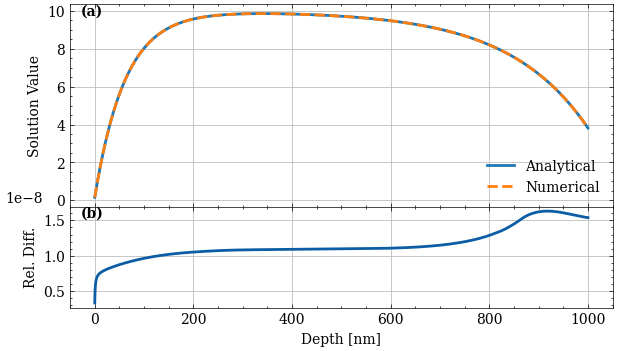

In [22]:
import scienceplots
import matplotlib
plt.style.use('science')
matplotlib.rcParams['text.usetex'] = False
# Calculate relative difference
relative_diff = (c_general(z, I0, D, v, L_a, L, S) -  c_num )/ c_general(z, I0, D, v, L_a, L, S)

# Create figure and axes with GridSpec (to eliminate vertical spacing)
fig = plt.figure(figsize=(7, 3.9375))
gs = fig.add_gridspec(2, 1, height_ratios=[2, 1], hspace=0)  # <== hspace=0 removes gap

# Top panel: Analytical vs Numerical
ax1 = fig.add_subplot(gs[0])
ax1.plot(z, c_general(z, I0, D, v, L_a, L, S), label='Analytical', color='tab:blue', linewidth=2)
ax1.plot(z, c_num, label='Numerical', color='tab:orange', linestyle='--', linewidth=2)
ax1.set_ylabel('Solution Value')
ax1.set_xlabel('')
ax1.legend(loc='best')
ax1.grid(True)
plt.setp(ax1.get_xticklabels(), visible=False)


# Bottom panel: Relative Difference
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax2.plot(z, relative_diff, linewidth=2)
ax2.set_xlabel('Depth [nm]')
ax2.set_ylabel('Rel. Diff.')
ax2.grid(True)

# Move scientific notation offset text to the left
ax2.yaxis.offsetText.set_x(-0.12)  # Push the '1e-10' label left of the y-axi

ax1.text(0.02, 1, '(a)', transform=ax1.transAxes, fontweight='bold', va='top')
ax2.text(0.02, 1, '(b)', transform=ax2.transAxes, fontweight='bold', va='top')

# Save and show
fig.savefig('/home/owner/claude_info/analytical_solution_comparison.png', dpi=300, transparent=True, bbox_inches='tight')
plt.show()


## 2. Mesh convergence

The FD scheme is second-order: with a full-precision reference (moderate $L$)
the error scales as $O(\Delta z^2)=O(N^{-2})$. Same parameters as §1.

N=    100  dz=10.0000 nm  max rel error=4.76e-03
N=    215  dz=4.6512 nm  max rel error=1.02e-03
N=    464  dz=2.1552 nm  max rel error=2.17e-04
N=  1,000  dz=1.0000 nm  max rel error=4.67e-05
N=  2,154  dz=0.4643 nm  max rel error=1.01e-05
N=  4,641  dz=0.2155 nm  max rel error=2.16e-06
N= 10,000  dz=0.1000 nm  max rel error=4.66e-07
N= 21,544  dz=0.0464 nm  max rel error=1.01e-07
N= 46,415  dz=0.0215 nm  max rel error=2.02e-08
N=100,000  dz=0.0100 nm  max rel error=1.63e-08


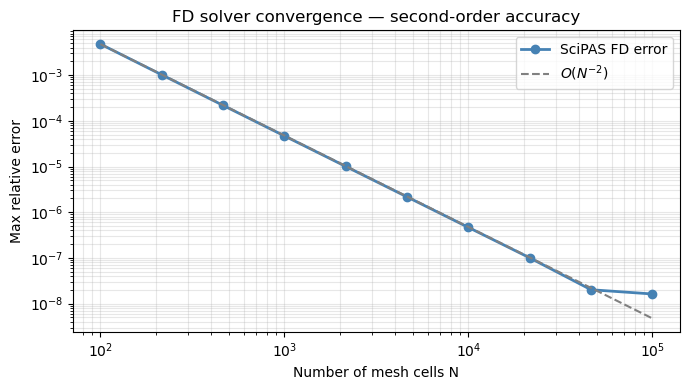

In [12]:
D, v, L_a, L, S = 1.0, -1e-2, 1.0, 100.0, 1000.0
mesh_sizes =  [int(i) for i in np.geomspace(1e2, 1e5, 10)]
errors = []
for N in mesh_sizes:
    z, c_num, I0 = run_solver(D=D, v=v, lam=D / L**2, L_a=L_a, S=S, mesh=N, field=True)
    ref = c_general(z, I0, D, v, L_a, L, S)
    m   = np.abs(ref) > 1e-2 * np.abs(ref).max()
    err = (np.abs(c_num[m] - ref[m]) / np.abs(ref[m])).max()
    errors.append(err)
    print(f'N={N:>7,}  dz={S/N:.4f} nm  max rel error={err:.2e}')

fig, ax = plt.subplots(figsize=(7, 4))
N = np.array(mesh_sizes, float)
ax.loglog(N, errors, 'o-', color='steelblue', lw=2, label='SciPAS FD error')
ax.loglog(N, errors[0] * (N[0] / N)**2, '--', color='gray', label=r'$O(N^{-2})$')
ax.set_xlabel('Number of mesh cells N'); ax.set_ylabel('Max relative error')
ax.set_title('FD solver convergence — second-order accuracy')
ax.legend(); ax.grid(alpha=0.3, which='both')
fig.tight_layout(); plt.show()